# Gaussian backfill / DFTracer O3 report

This report is generated from the validated 12-arm Tuolumne pdebug
matrix. It compares Fluxion baseline and `skip-empty-dfu-expansion`
across easy, hybrid, and conservative backfilling, with both ordinary
core-bearing jobspecs and node-only jobspecs.

Every arm uses the same 500-job Gaussian trace, 128 nodes × 96 cores,
`lonodex`, `rv1_nosched`, reservation depth 4, queue depth 1024,
Release/O3 Fluxion, and DFTracer annotation level 2. Validator and
frobnicator plugins are disabled for the node-only jobspec arms.


In [1]:
from __future__ import annotations

import gzip
import json
from pathlib import Path

import pandas as pd
from IPython.display import display
from plotnine import (
    aes,
    element_text,
    facet_grid,
    facet_wrap,
    geom_boxplot,
    geom_col,
    geom_hline,
    ggplot,
    labs,
    position_dodge,
    scale_fill_manual,
    theme,
    theme_minimal,
)

ROOT = Path('/p/lustre5/ashworth12/dftracer-gaussian-backfill-rd4-o3-final-20260730_052656')
POLICY_ORDER = ['easy', 'hybrid', 'conservative']
SHAPE_ORDER = ['cores', 'no-cores']
VARIANT_ORDER = ['baseline', 'skip-empty-dfu-expansion']
COLORS = ['#4C78A8', '#F58518']

provenance = json.loads((ROOT / 'scheduler_provenance.json').read_text())
validation = json.loads((ROOT / 'dftracer_trace_validation.json').read_text())
return_codes = (ROOT / 'matrix_return_codes.txt').read_text().strip()

assert provenance['cmake_build_type'] == 'Release'
assert provenance['dftracer_annotation_level'] == 2
assert validation['trace_count'] == 12
assert all(item['run_match_events_with_jobid'] > 0 for item in validation['traces'])
print(f'Validated result root: {ROOT}')
print(return_codes)
display(pd.DataFrame({
    'variant': ['baseline', 'skip-empty-dfu-expansion'],
    'revision': [
        provenance['baseline']['revision'],
        provenance['skip_empty_dfu_expansion']['revision'],
    ],
}))


Validated result root: /p/lustre5/ashworth12/dftracer-gaussian-backfill-rd4-o3-final-20260730_052656
baseline=0
skip_empty_dfu_expansion=0


,variant,revision
0,baseline,d21ef77a555f593bde5a6f26ce2ef3a480c599e8
1,skip-empty-dfu-expansion,8ad647688840fd8349ccf54a37f064831be318bc


## Run completion and wall time

`wall_seconds` is real elapsed time for each child simulation. Shared
clock deliberately fast-forwards through idle simulated time, so it is
expected to be much shorter than the approximately 10.3–10.5 hours of
simulated makespan. All twelve children ran concurrently on the same
pdebug node; wall-time differences are therefore useful as a first A/B,
but this is one replicate and includes cross-run CPU contention.


,policy,jobspec_shape,variant,jobs_completed,wall_minutes,makespan_hours
0,easy,cores,baseline,500,4.517,10.273
1,easy,cores,skip-empty-dfu-expansion,500,6.867,10.359
2,hybrid,cores,baseline,500,8.817,10.477
3,hybrid,cores,skip-empty-dfu-expansion,500,6.433,10.477
4,conservative,cores,baseline,500,12.433,10.393
5,conservative,cores,skip-empty-dfu-expansion,500,14.133,10.393
6,easy,no-cores,baseline,500,1.167,10.273
7,easy,no-cores,skip-empty-dfu-expansion,500,0.967,10.273
8,hybrid,no-cores,baseline,500,2.950,10.398
9,hybrid,no-cores,skip-empty-dfu-expansion,500,2.050,10.412


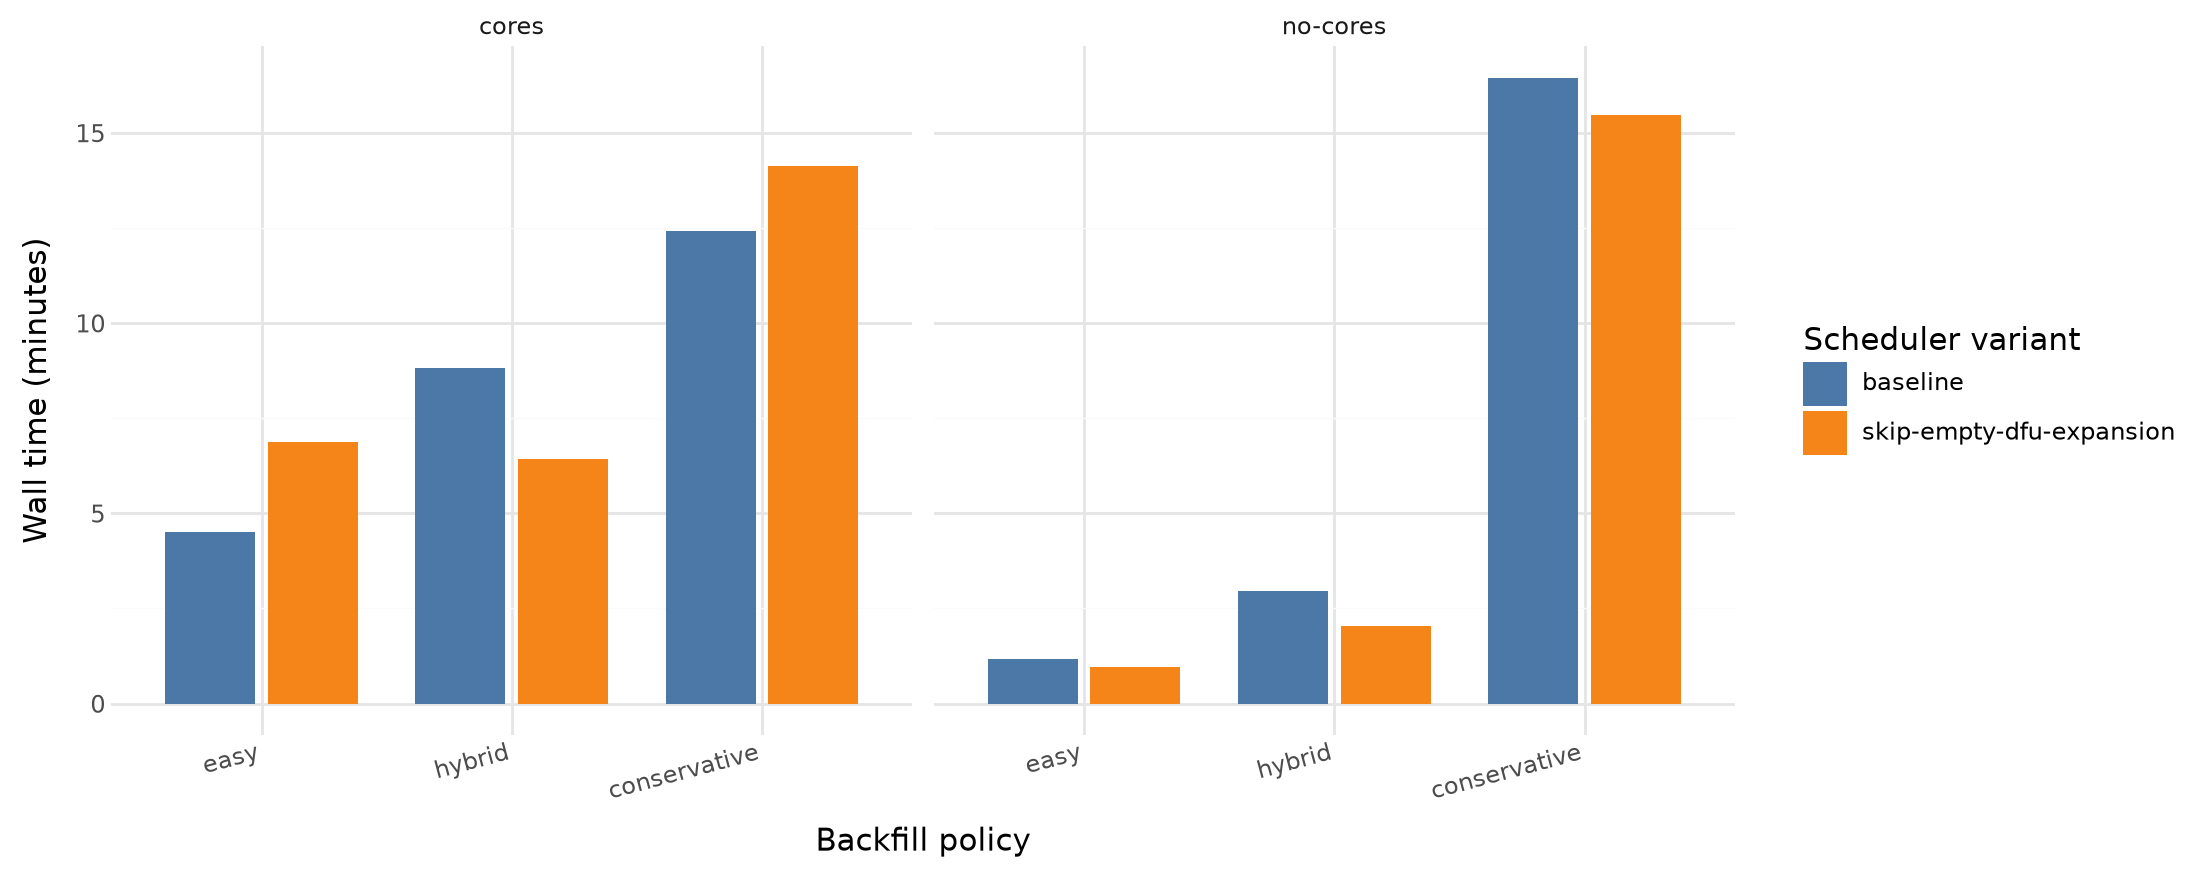

In [2]:
run_rows = []
for status_path in sorted(ROOT.glob('runs/*/*/parallel_status.json')):
    status = json.loads(status_path.read_text())
    for run in status['runs']:
        metadata = run['metadata']
        run_rows.append({
            'variant': metadata['scheduler_variant'],
            'policy': metadata['queue_policy'],
            'jobspec_shape': metadata['jobspec_shape'],
            'state': run['state'],
            'jobs_total': run['jobs_total'],
            'jobs_submitted': run['jobs_submitted'],
            'jobs_started': run['jobs_started'],
            'jobs_completed': run['jobs_completed'],
            'wall_seconds': float(run['wall_seconds']),
            'sim_wall_seconds': float(run['sim_wall_seconds']),
            'makespan_hours': float(run['makespan_hours']),
        })

runs = pd.DataFrame(run_rows)
runs['policy'] = pd.Categorical(runs['policy'], POLICY_ORDER, ordered=True)
runs['jobspec_shape'] = pd.Categorical(runs['jobspec_shape'], SHAPE_ORDER, ordered=True)
runs['variant'] = pd.Categorical(runs['variant'], VARIANT_ORDER, ordered=True)
runs['wall_minutes'] = runs['wall_seconds'] / 60.0
runs = runs.sort_values(['jobspec_shape', 'policy', 'variant']).reset_index(drop=True)

assert len(runs) == 12
assert (runs['state'] == 'succeeded').all()
assert (runs[['jobs_total', 'jobs_submitted', 'jobs_started', 'jobs_completed']] == 500).all().all()
display(runs[['policy', 'jobspec_shape', 'variant', 'jobs_completed',
              'wall_minutes', 'makespan_hours']].round(3))

(
    ggplot(runs, aes('policy', 'wall_minutes', fill='variant'))
    + geom_col(position=position_dodge(width=0.82), width=0.72)
    + facet_wrap('~jobspec_shape', nrow=1)
    + scale_fill_manual(values=COLORS)
    + labs(
        # title='Real wall time for every 500-job simulation',
        x='Backfill policy', y='Wall time (minutes)', fill='Scheduler variant',
    )
    + theme_minimal()
    + theme(figure_size=(11, 4.4),plot_title=element_text(ha="center"),plot_subtitle=element_text(ha="center"), axis_text_x=element_text(rotation=15, ha='right'))
)


## How often each job was considered

A `run_match` span is emitted once for each allocation or reservation
attempt. Grouping those spans by `args.jobid` directly answers how often
a job was reconsidered in the scheduler loop. This is not the same as
job count: each of the 500 jobs can appear many times before it starts.


,policy,jobspec_shape,variant,unique_jobids,mean_considerations,median_considerations,p95_considerations,max_considerations,merged_events,run_match_events
0,conservative,cores,baseline,500,57.31,61.0,101.00,136,110760,28653
1,conservative,cores,skip-empty-dfu-expansion,500,57.31,61.0,101.00,136,110760,28653
4,easy,cores,baseline,500,47.64,48.0,110.00,143,73912,23822
5,easy,cores,skip-empty-dfu-expansion,500,47.58,48.0,112.05,144,73848,23790
8,hybrid,cores,baseline,500,59.92,66.0,109.05,135,89076,29962
9,hybrid,cores,skip-empty-dfu-expansion,500,59.92,66.0,109.05,135,89076,29962
2,conservative,no-cores,baseline,500,57.31,61.0,101.00,136,110760,28653
3,conservative,no-cores,skip-empty-dfu-expansion,500,57.31,61.0,101.00,136,110760,28653
6,easy,no-cores,baseline,500,47.65,48.0,110.00,143,73922,23827
7,easy,no-cores,skip-empty-dfu-expansion,500,47.65,48.0,110.00,143,73922,23827


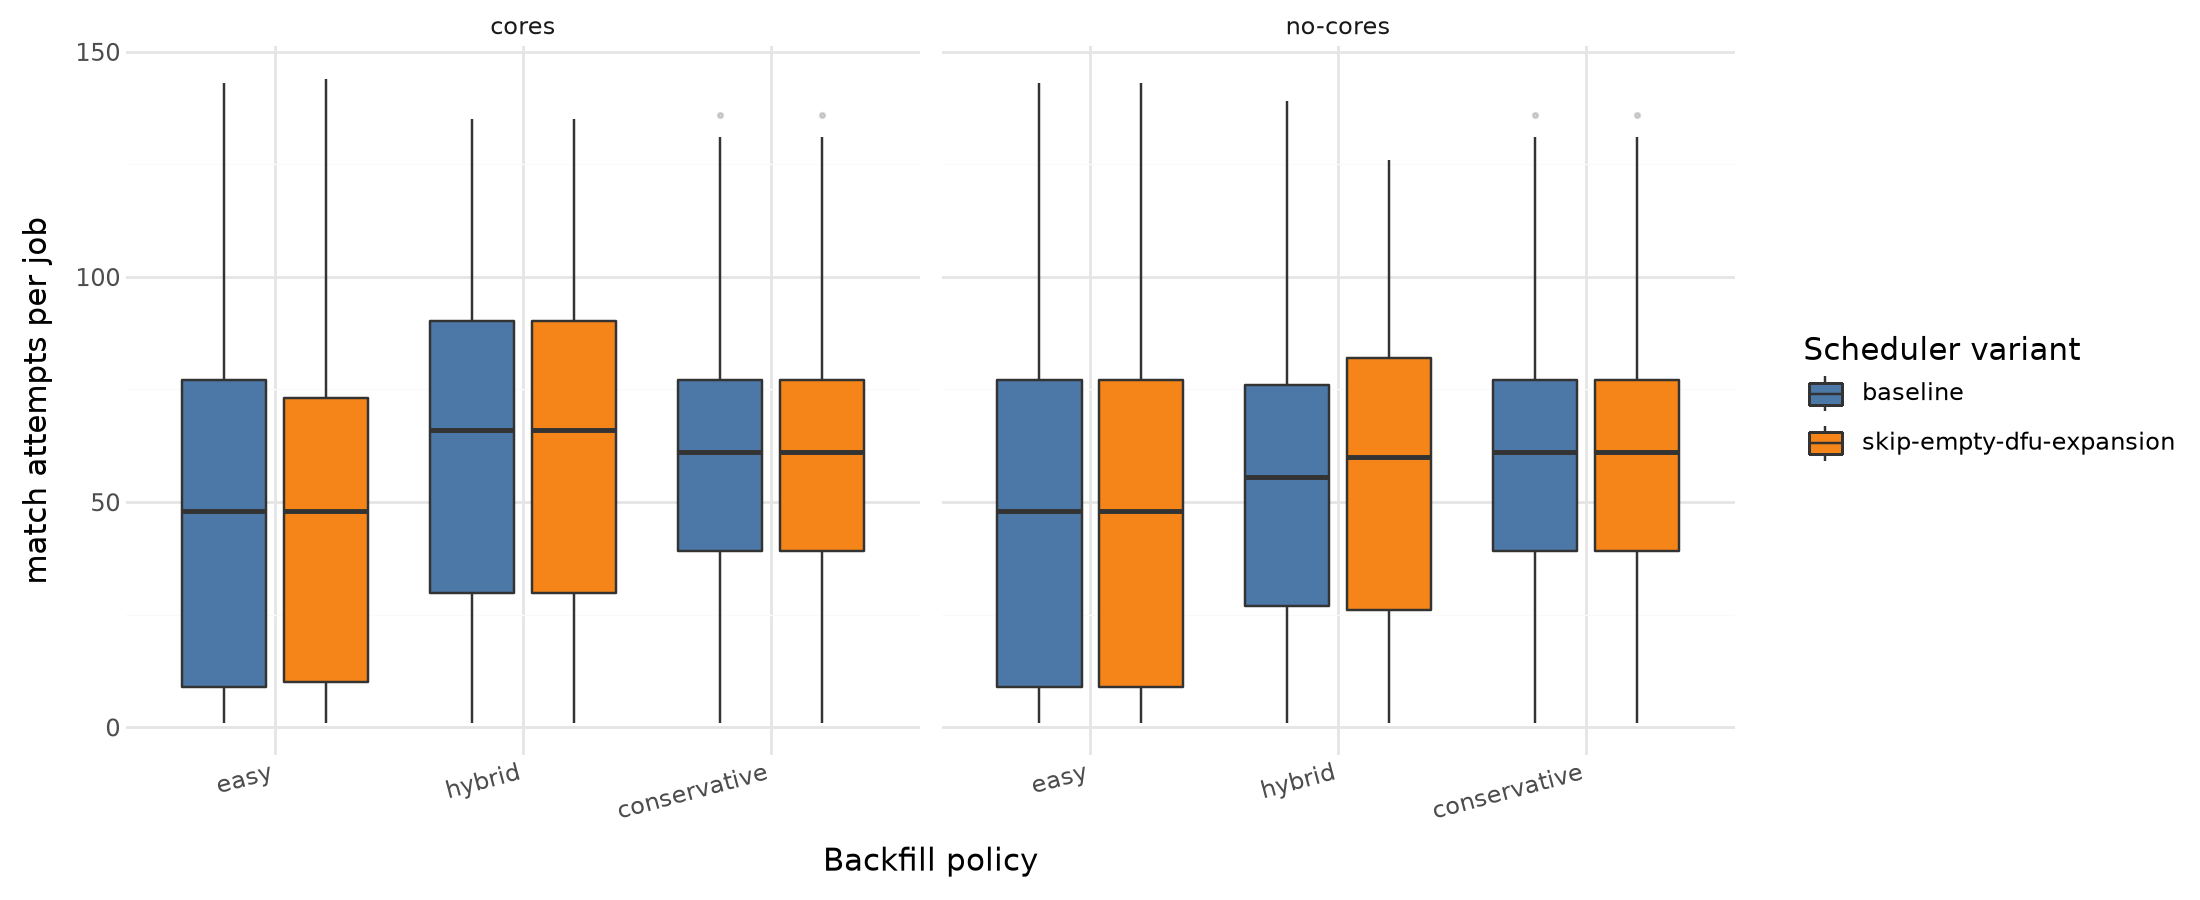

In [5]:
def pfw_events(path: Path):
    with gzip.open(path, 'rt', encoding='utf-8') as stream:
        for raw in stream:
            raw = raw.strip().rstrip(',')
            if raw in {'', '[', ']'}:
                continue
            yield json.loads(raw)


match_rows = []
trace_rows = []
for item in validation['traces']:
    trace = Path(item['trace'])
    variant = trace.parent.parent.name
    slug = trace.parent.name.split('_', 1)[1]
    jobspec_shape = 'no-cores' if slug.endswith('no-cores') else 'cores'
    policy = slug.removesuffix('-' + jobspec_shape)
    matched = 0
    for event in pfw_events(trace):
        args = event.get('args')
        if event.get('name') != 'run_match' or not isinstance(args, dict) or 'jobid' not in args:
            continue
        matched += 1
        match_rows.append({
            'variant': variant,
            'policy': policy,
            'jobspec_shape': jobspec_shape,
            'jobid': str(args['jobid']),
            'run_match_ms': float(event['dur']) / 1_000_000.0,
        })
    trace_rows.append({
        'variant': variant,
        'policy': policy,
        'jobspec_shape': jobspec_shape,
        'merged_events': item['events'],
        'run_match_events': matched,
    })

matches = pd.DataFrame(match_rows)
traces = pd.DataFrame(trace_rows)
per_job = (
    matches.groupby(['variant', 'policy', 'jobspec_shape', 'jobid'], as_index=False)
    .agg(match_attempts=('jobid', 'size'), total_match_ms=('run_match_ms', 'sum'))
)
coverage = (
    per_job.groupby(['policy', 'jobspec_shape', 'variant'], as_index=False)
    .agg(
        unique_jobids=('jobid', 'nunique'),
        mean_considerations=('match_attempts', 'mean'),
        median_considerations=('match_attempts', 'median'),
        p95_considerations=('match_attempts', lambda x: x.quantile(0.95)),
        max_considerations=('match_attempts', 'max'),
    )
    .merge(traces, on=['policy', 'jobspec_shape', 'variant'])
)
assert len(coverage) == 12
assert (coverage['unique_jobids'] == 500).all()
assert (coverage['run_match_events'] > 0).all()
display(coverage.sort_values(['jobspec_shape', 'policy', 'variant']).round(2))

per_job['policy'] = pd.Categorical(per_job['policy'], POLICY_ORDER, ordered=True)
per_job['jobspec_shape'] = pd.Categorical(per_job['jobspec_shape'], SHAPE_ORDER, ordered=True)
per_job['variant'] = pd.Categorical(per_job['variant'], VARIANT_ORDER, ordered=True)
(
    ggplot(per_job, aes('policy', 'match_attempts', fill='variant'))
    + geom_boxplot(position=position_dodge(width=0.82), width=0.68,
                   outlier_alpha=0.18, outlier_size=0.5)
    + facet_wrap('~jobspec_shape', nrow=1)
    + scale_fill_manual(values=COLORS)
    + labs(
        # title='A job is considered dozens of times before it runs',
        # subtitle='500 job IDs per arm; boxes show the per-job run_match count',
        x='Backfill policy', y='match attempts per job',
        fill='Scheduler variant',
    )
    + theme_minimal()
    + theme(figure_size=(11, 4.5), axis_text_x=element_text(rotation=15, ha='right'))
)


## Matching cost and feature deltas

The next table combines trace-derived match time with child wall time.
`total_run_match_seconds` sums all level-2 `run_match` span durations;
it is the clearest scheduler-work measure in this trace. Percent deltas
are `(feature / baseline - 1) × 100`, so negative is faster/less work.


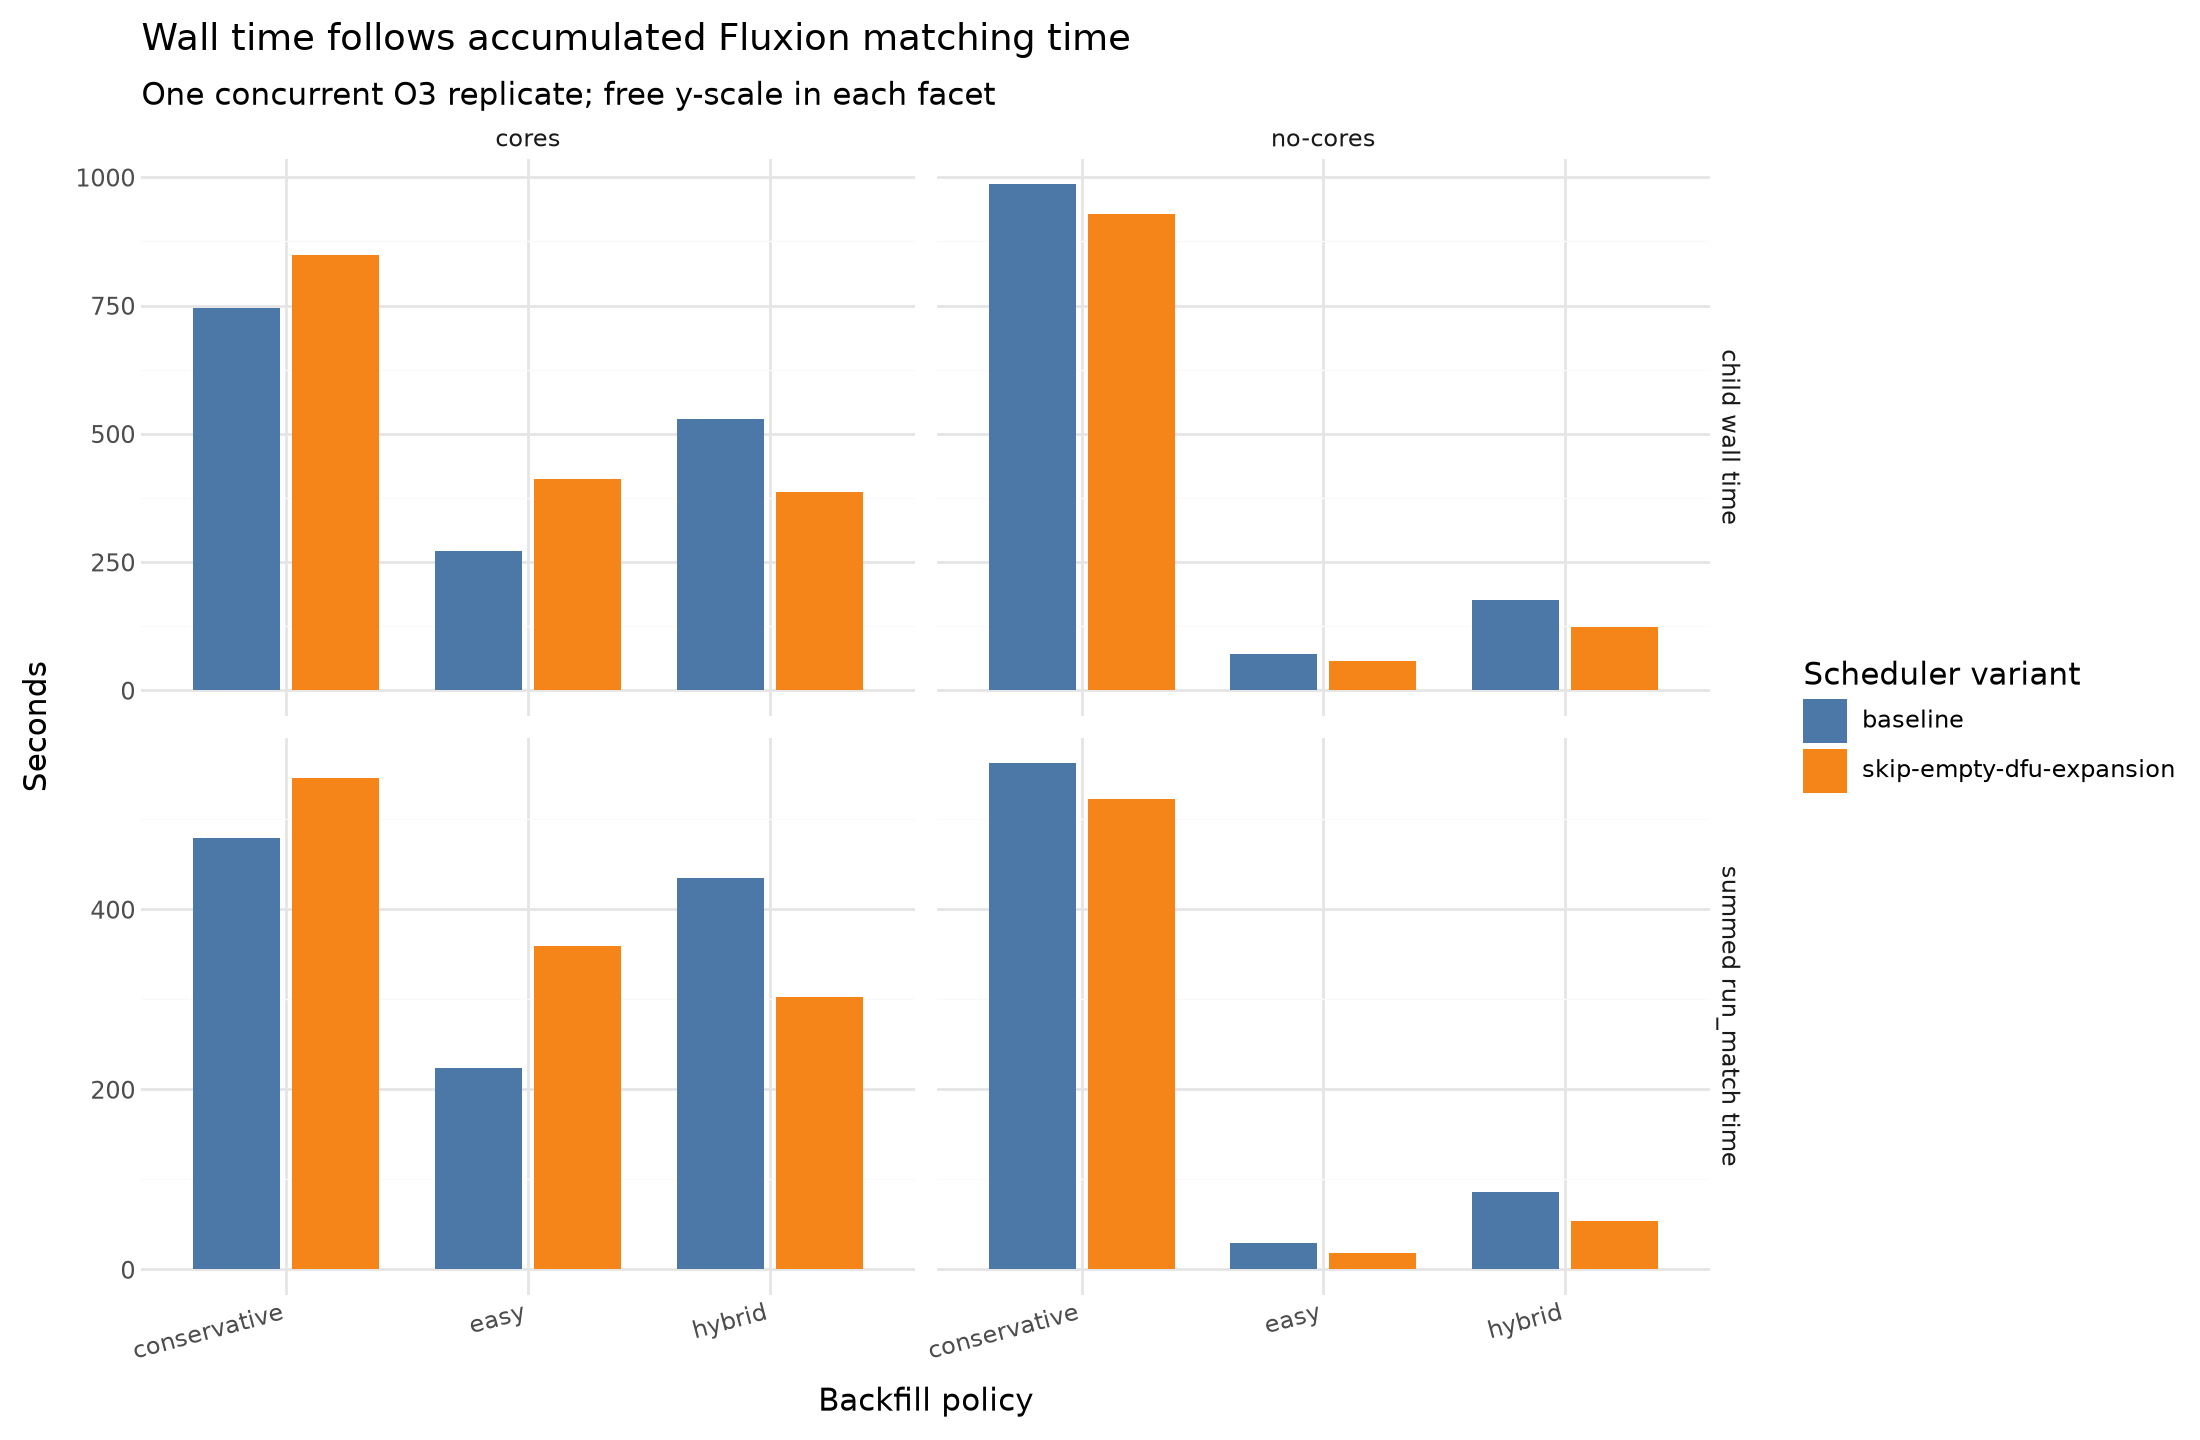

,policy,jobspec_shape,wall_seconds_baseline,wall_seconds_feature,wall_seconds_delta_pct,total_run_match_seconds_baseline,total_run_match_seconds_feature,total_run_match_seconds_delta_pct,run_match_events_baseline,run_match_events_feature,run_match_events_delta_pct
0,conservative,cores,746.0,848.0,13.67,479.15,545.54,13.86,28653.0,28653.0,0.00
1,easy,cores,271.0,412.0,52.03,224.08,359.35,60.37,23822.0,23790.0,-0.13
2,hybrid,cores,529.0,386.0,-27.03,434.38,302.15,-30.44,29962.0,29962.0,0.00
3,conservative,no-cores,987.0,929.0,-5.88,562.56,522.28,-7.16,28653.0,28653.0,0.00
4,easy,no-cores,70.0,58.0,-17.14,29.96,18.65,-37.74,23827.0,23827.0,0.00
5,hybrid,no-cores,177.0,123.0,-30.51,86.16,53.60,-37.79,26540.0,27883.0,5.06


In [4]:
match_metrics = (
    matches.groupby(['policy', 'jobspec_shape', 'variant'], as_index=False)
    .agg(
        run_match_events=('jobid', 'size'),
        mean_run_match_ms=('run_match_ms', 'mean'),
        p95_run_match_ms=('run_match_ms', lambda x: x.quantile(0.95)),
        total_run_match_ms=('run_match_ms', 'sum'),
    )
)
metrics = runs.merge(match_metrics, on=['policy', 'jobspec_shape', 'variant'])
metrics['total_run_match_seconds'] = metrics['total_run_match_ms'] / 1000.0

metric_long = metrics.melt(
    id_vars=['policy', 'jobspec_shape', 'variant'],
    value_vars=['wall_seconds', 'total_run_match_seconds'],
    var_name='metric', value_name='seconds',
)
metric_long['metric'] = metric_long['metric'].map({
    'wall_seconds': 'child wall time',
    'total_run_match_seconds': 'summed run_match time',
})
metric_plot = (
    ggplot(metric_long, aes('policy', 'seconds', fill='variant'))
    + geom_col(position=position_dodge(width=0.82), width=0.72)
    + facet_grid('metric ~ jobspec_shape', scales='free_y')
    + scale_fill_manual(values=COLORS)
    + labs(
        title='Wall time follows accumulated Fluxion matching time',
        subtitle='One concurrent O3 replicate; free y-scale in each facet',
        x='Backfill policy', y='Seconds', fill='Scheduler variant',
    )
    + theme_minimal()
    + theme(figure_size=(11, 7.2), axis_text_x=element_text(rotation=15, ha='right'))
)
display(metric_plot)

paired = metrics.pivot(
    index=['policy', 'jobspec_shape'], columns='variant',
    values=['wall_seconds', 'total_run_match_seconds', 'run_match_events'],
)
deltas = paired.index.to_frame(index=False)
for metric in ['wall_seconds', 'total_run_match_seconds', 'run_match_events']:
    base = paired[(metric, 'baseline')].to_numpy()
    feature = paired[(metric, 'skip-empty-dfu-expansion')].to_numpy()
    deltas[metric + '_baseline'] = base
    deltas[metric + '_feature'] = feature
    deltas[metric + '_delta_pct'] = 100.0 * (feature / base - 1.0)
deltas = deltas.sort_values(['jobspec_shape', 'policy']).reset_index(drop=True)
display(deltas.round(2))


## Findings

- The test is complete, not an early exit: all 12 arms submitted,
  started, and completed 500/500 jobs. Each merged trace contains all
  500 distinct job IDs in `run_match` metadata.
- Jobs are reconsidered frequently. Depending on policy, the median is
  roughly 48–66 considerations per job, the 95th percentile is about
  101–112, and individual jobs reach roughly 126–144 attempts.
- In this single concurrent O3 replicate, `skip-empty-dfu-expansion`
  reduced hybrid/core wall time by about 27% and summed matching time by
  about 30%. Hybrid/no-core improved by about 31% wall time despite
  about 5% more outer match attempts.
- Easy/no-core improved, while easy/core and conservative/core regressed
  in this replicate. Those reversals are a reason to run replicated or
  paired-isolated measurements before treating the percentages as stable
  performance estimates.
- The complete pdebug allocation took 18.3 real minutes because shared
  clock skips idle simulated time, O3 accelerates Fluxion, and all 12
  arms ran concurrently. The child wall times above—not the simulated
  makespan—are the relevant runtime measurements.
